# Liver Disease — Model Training and Evaluation

This notebook trains and evaluates a leakage-safe binary classifier using the cleaned UCI ILPD dataset.

The workflow includes stratified development/validation/test splitting, preprocessing inside pipelines, a majority-class baseline, five-fold cross-validation, model comparison, validation-only threshold tuning, untouched-test evaluation, sex-stratified metrics, permutation feature importance, and model serialization.

**Target:** `liver_disease` (`0` = No liver disease, `1` = Liver disease)  
**Source:** UCI Machine Learning Repository — ILPD (Dataset ID 225)  
**License:** CC BY 4.0  
**Important:** This model is an educational screening demonstration and is not a medical diagnosis.

## 1. Training Environment and Reproducibility

The notebook imports the preprocessing, modeling, evaluation, visualization, and serialization tools required for the liver-disease experiment.

A fixed random state is used where applicable so that the data partitions and stochastic model behavior can be reproduced consistently.


In [1]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler


# Configure reproducibility and display
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the project root from either the project or notebooks folder
current_folder = Path.cwd()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

data_path = project_root / "data" / "processed" / "liver_disease_clean.csv"
models_folder = project_root / "models"
figures_folder = project_root / "reports" / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

model_path = models_folder / "liver_disease_model.joblib"
evaluation_figure_path = figures_folder / "liver_final_model_evaluation.png"
importance_figure_path = figures_folder / "liver_feature_importance.png"

print("Processed dataset path:", data_path)
print("File exists:", data_path.exists())

if not data_path.exists():
    raise FileNotFoundError(
        "Run 07_liver_disease_data_exploration.ipynb first to create "
        "data/processed/liver_disease_clean.csv."
    )

Processed dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\liver_disease_clean.csv
File exists: True


## 2. Loading and Validating the Processed Liver Dataset

The cleaned dataset produced by the exploration notebook is loaded and checked before training.

The target is separated from the predictors, and the notebook confirms the data structure, class distribution, missing values, and feature availability. These checks reduce the risk of silently training on an incorrectly prepared dataset.


In [2]:
# Load and validate the cleaned dataset
liver_data = pd.read_csv(data_path)
target_column = "liver_disease"

if target_column not in liver_data.columns:
    raise ValueError(f"Required target column is missing: {target_column}")

if liver_data[target_column].isnull().any():
    raise ValueError("The target contains missing values.")

if liver_data.duplicated().any():
    raise ValueError("The processed dataset still contains exact duplicates.")

X = liver_data.drop(columns=[target_column]).copy()
y = liver_data[target_column].astype(int).copy()

if set(y.unique()) != {0, 1}:
    raise ValueError(f"Unexpected target values: {sorted(y.unique())}")

print("Full dataset shape:", liver_data.shape)
print("Feature matrix shape:", X.shape)
print("Total missing feature values:", int(X.isnull().sum().sum()))
print("\nTarget distribution (%):")
print(y.value_counts(normalize=True).sort_index().mul(100).round(2))
print("\nGender-target table:")
display(pd.crosstab(X["gender"], y, margins=True))
display(liver_data.head())

Full dataset shape: (570, 11)
Feature matrix shape: (570, 10)
Total missing feature values: 4

Target distribution (%):
liver_disease
0    28.77
1    71.23
Name: proportion, dtype: float64

Gender-target table:


liver_disease,0,1,All
gender,,,
female,49,91,140
male,115,315,430
All,164,406,570


,age,gender,total_bilirubin,direct_bilirubin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,total_proteins,albumin,albumin_globulin_ratio,liver_disease
0,65,female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Leakage-safe split design

- **Development (64%)** — fitting and five-fold cross-validation.
- **Validation (16%)** — threshold tuning and confirmation only.
- **Test (20%)** — final evaluation once after every modeling decision is fixed.

All splits are stratified by the target. Imputation, encoding, power transformation, and scaling are fitted only through scikit-learn pipelines.

## 3. Leakage-Safe Data Splitting

The data are divided into development, validation, and untouched test subsets before any fitted preprocessing is applied.

- **Development set:** used for cross-validation and fitting candidate models.
- **Validation set:** used to compare behavior and select the decision threshold.
- **Test set:** reserved for one final evaluation.

This structure protects the test set from influencing model selection.


In [3]:
# Create the untouched test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Create development and validation sets from the remaining records
X_development, X_validation, y_development, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

def target_percentages(target):
    return target.value_counts(normalize=True).sort_index().mul(100).round(2)

print("Development features shape:", X_development.shape)
print("Validation features shape:", X_validation.shape)
print("Testing features shape:", X_test.shape)
print("\nDevelopment target distribution (%):")
print(target_percentages(y_development))
print("\nValidation target distribution (%):")
print(target_percentages(y_validation))
print("\nTesting target distribution (%):")
print(target_percentages(y_test))

# Confirm that exact feature profiles do not overlap across splits
development_profiles = set(map(tuple, X_development.fillna("<MISSING>").to_numpy()))
validation_profiles = set(map(tuple, X_validation.fillna("<MISSING>").to_numpy()))
test_profiles = set(map(tuple, X_test.fillna("<MISSING>").to_numpy()))

print("\nDevelopment-validation overlap:", len(development_profiles & validation_profiles))
print("Development-test overlap:", len(development_profiles & test_profiles))
print("Validation-test overlap:", len(validation_profiles & test_profiles))

Development features shape: (364, 10)
Validation features shape: (92, 10)
Testing features shape: (114, 10)

Development target distribution (%):
liver_disease
0    28.85
1    71.15
Name: proportion, dtype: float64

Validation target distribution (%):
liver_disease
0    28.26
1    71.74
Name: proportion, dtype: float64

Testing target distribution (%):
liver_disease
0    28.95
1    71.05
Name: proportion, dtype: float64

Development-validation overlap: 0
Development-test overlap: 0
Validation-test overlap: 0


## 4. Feature Groups, Preprocessing, and Candidate Pipelines

Numerical and categorical variables are handled separately.

Typical pipeline operations include:

- Median imputation for numerical missing values.
- Most-frequent imputation for categorical missing values.
- One-hot encoding for categorical predictors.
- Feature scaling where required by the classifier.

Multiple candidate models are constructed under the same leakage-safe preprocessing framework so their performance can be compared fairly.


In [4]:
# Define feature groups
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# The power transform reduces extreme right-skew for the linear model
linear_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("power_transform", PowerTransformer(method="yeo-johnson", standardize=False)),
        ("scaler", StandardScaler()),
    ]
)

tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", linear_numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", tree_numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

candidate_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "HistGradientBoosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                HistGradientBoostingClassifier(
                    max_iter=200,
                    learning_rate=0.05,
                    max_leaf_nodes=15,
                    min_samples_leaf=15,
                    l2_regularization=1.0,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

Numerical features: ['age', 'total_bilirubin', 'direct_bilirubin', 'alkaline_phosphatase', 'alanine_aminotransferase', 'aspartate_aminotransferase', 'total_proteins', 'albumin', 'albumin_globulin_ratio']
Categorical features: ['gender']


## 5. Common Evaluation Metrics and Baseline

A reusable metric function is defined to report several complementary measures rather than relying on accuracy alone.

The evaluation includes accuracy, balanced accuracy, precision, recall, F1 score, ROC-AUC, and PR-AUC.

These metrics are particularly useful when the classes are not perfectly balanced and when detecting positive disease cases is important.


In [5]:
# Define reusable binary-classification metrics
def calculate_metrics(y_true, predictions, scores):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
    }

# Establish the majority-class validation baseline
majority_class = int(y_development.mode().iloc[0])
baseline_predictions = np.full(len(y_validation), majority_class)
baseline_scores = np.full(len(y_validation), y_development.mean())

results = {
    "Majority Class Baseline": {
        **calculate_metrics(y_validation, baseline_predictions, baseline_scores),
        "Training Time (s)": np.nan,
    }
}

print("Majority class:", majority_class)
print("Baseline confusion matrix:")
print(confusion_matrix(y_validation, baseline_predictions))
display(pd.DataFrame(results).T.round(4))

Majority class: 1
Baseline confusion matrix:
[[ 0 26]
 [ 0 66]]


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Majority Class Baseline,0.7174,0.5,0.7174,1.0,0.8354,0.5,0.7174,NaN


## 6. Five-Fold Cross-Validation

Each candidate pipeline is evaluated with stratified five-fold cross-validation on the development subset.

Cross-validation estimates both average performance and variation across folds. Balanced accuracy, F1, ROC-AUC, and PR-AUC are tracked to assess model quality from several perspectives without touching the final test set.


In [6]:
# Evaluate model stability using stratified five-fold cross-validation
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

cv_rows = []
for model_name, model_pipeline in candidate_models.items():
    scores = cross_validate(
        model_pipeline,
        X_development,
        y_development,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_rows.append(
        {
            "Model": model_name,
            "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
            "Balanced Accuracy SD": scores["test_balanced_accuracy"].std(),
            "F1 Mean": scores["test_f1"].mean(),
            "F1 SD": scores["test_f1"].std(),
            "ROC-AUC Mean": scores["test_roc_auc"].mean(),
            "ROC-AUC SD": scores["test_roc_auc"].std(),
            "PR-AUC Mean": scores["test_pr_auc"].mean(),
            "PR-AUC SD": scores["test_pr_auc"].std(),
        }
    )

cv_results = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results.round(4))

,Balanced Accuracy Mean,Balanced Accuracy SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD,PR-AUC Mean,PR-AUC SD
Model,,,,,,,,
Logistic Regression,0.6554,0.0296,0.7012,0.0309,0.7236,0.0448,0.8768,0.0349
Random Forest,0.6452,0.0436,0.7333,0.0521,0.7226,0.0629,0.8709,0.0505
HistGradientBoosting,0.6067,0.0628,0.7558,0.0317,0.7065,0.0691,0.8687,0.0478


## 7. Validation-Set Comparison

Candidate models are fitted on development data and then evaluated on the separate validation set using the default 0.50 threshold.

The resulting confusion matrices, metrics, and training times provide an independent comparison after cross-validation and help confirm whether model behavior is stable.


In [7]:
# Fit candidate models on development data and score validation data
fitted_development_models = {}

for model_name, model_pipeline in candidate_models.items():
    start_time = time.perf_counter()
    fitted_model = clone(model_pipeline)
    fitted_model.fit(X_development, y_development)
    training_time = time.perf_counter() - start_time

    validation_scores = fitted_model.predict_proba(X_validation)[:, 1]
    validation_predictions = (validation_scores >= 0.50).astype(int)

    results[model_name] = {
        **calculate_metrics(y_validation, validation_predictions, validation_scores),
        "Training Time (s)": training_time,
    }
    fitted_development_models[model_name] = fitted_model

    print(f"{model_name} confusion matrix:")
    print(confusion_matrix(y_validation, validation_predictions))
    print(f"Training time: {training_time:.4f} seconds\n")

validation_results = pd.DataFrame(results).T
display(validation_results.round(4))

Logistic Regression confusion matrix:
[[17  9]
 [23 43]]
Training time: 0.3330 seconds

Random Forest confusion matrix:
[[14 12]
 [18 48]]
Training time: 1.6214 seconds

HistGradientBoosting confusion matrix:
[[11 15]
 [15 51]]
Training time: 0.8267 seconds



,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Majority Class Baseline,0.7174,0.5000,0.7174,1.0000,0.8354,0.5000,0.7174,NaN
Logistic Regression,0.6522,0.6527,0.8269,0.6515,0.7288,0.7232,0.8767,0.3330
Random Forest,0.6739,0.6329,0.8000,0.7273,0.7619,0.6888,0.8594,1.6214
HistGradientBoosting,0.6739,0.5979,0.7727,0.7727,0.7727,0.7075,0.8745,0.8267


## Model and threshold selection

The model is selected using mean development cross-validation balanced accuracy, with PR-AUC as the tie-breaker. This avoids selecting a model solely because the positive class is the majority. For screening, threshold selection requires at least 80% validation recall and then maximizes balanced accuracy; precision and F1 resolve ties. The final test set remains untouched.

## 8. Model Selection and Threshold Optimization

The model is selected from development cross-validation results, primarily using balanced accuracy and PR-AUC.

Its validation probabilities are then evaluated across many possible decision thresholds. The procedure first requires at least 80% recall when possible, then favors stronger balanced accuracy, precision, and F1 score.

The threshold is selected from validation data only. It is an operating point for this model, not a clinical diagnostic cutoff.


In [8]:
# Select the model from development cross-validation only
selected_model_name = cv_results.sort_values(
    ["Balanced Accuracy Mean", "PR-AUC Mean"],
    ascending=False,
).index[0]

selected_development_model = fitted_development_models[selected_model_name]
validation_scores = selected_development_model.predict_proba(X_validation)[:, 1]

# Tune the decision threshold using validation data only
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 901):
    predictions = (validation_scores >= threshold).astype(int)
    threshold_rows.append(
        {
            "Threshold": threshold,
            "Balanced Accuracy": balanced_accuracy_score(y_validation, predictions),
            "Precision": precision_score(y_validation, predictions, zero_division=0),
            "Recall": recall_score(y_validation, predictions, zero_division=0),
            "F1 Score": f1_score(y_validation, predictions, zero_division=0),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)

# Require screening sensitivity before optimizing the remaining trade-offs
eligible_thresholds = threshold_results.loc[
    threshold_results["Recall"] >= 0.80
].copy()

if eligible_thresholds.empty:
    eligible_thresholds = threshold_results.copy()

best_threshold_row = eligible_thresholds.sort_values(
    ["Balanced Accuracy", "Precision", "F1 Score"],
    ascending=False,
).iloc[0]

selected_threshold = float(best_threshold_row["Threshold"])
tuned_validation_predictions = (validation_scores >= selected_threshold).astype(int)
tuned_validation_metrics = calculate_metrics(
    y_validation,
    tuned_validation_predictions,
    validation_scores,
)

print("Selected model:", selected_model_name)
print(f"Selected threshold: {selected_threshold:.3f}")
print("Tuned validation confusion matrix:")
print(confusion_matrix(y_validation, tuned_validation_predictions))
display(
    pd.DataFrame(
        {
            "Selected Model Tuned": {
                **tuned_validation_metrics,
                "Threshold": selected_threshold,
            }
        }
    ).T.round(4)
)

Selected model: Logistic Regression
Selected threshold: 0.295
Tuned validation confusion matrix:
[[10 16]
 [ 4 62]]


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold
Selected Model Tuned,0.7826,0.662,0.7949,0.9394,0.8611,0.7232,0.8767,0.295


## 9. Final Refit and Held-Out Test Evaluation

After the model type and threshold are fixed, the selected pipeline is retrained using the combined development and validation data.

The untouched test set is then evaluated exactly once. These final metrics and the classification report are the official held-out performance values for the liver-disease experiment.


In [9]:
# Refit the selected model on development plus validation data
X_final_training = pd.concat([X_development, X_validation], axis=0)
y_final_training = pd.concat([y_development, y_validation], axis=0)

final_model = clone(candidate_models[selected_model_name])
start_time = time.perf_counter()
final_model.fit(X_final_training, y_final_training)
final_training_time = time.perf_counter() - start_time

# Evaluate exactly once on the untouched test set
test_scores = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_scores >= selected_threshold).astype(int)
test_metrics = calculate_metrics(y_test, test_predictions, test_scores)
test_confusion_matrix = confusion_matrix(y_test, test_predictions)

final_results = pd.DataFrame(
    {
        f"Final Liver {selected_model_name}": {
            **test_metrics,
            "Threshold": selected_threshold,
            "Training Time (s)": final_training_time,
        }
    }
).T

display(final_results.round(4))
print("Final liver disease test confusion matrix:")
print(test_confusion_matrix)
print(f"\nFinal training time: {final_training_time:.4f} seconds")
print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["No liver disease", "Liver disease"],
        digits=4,
    )
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold,Training Time (s)
Final Liver Logistic Regression,0.7368,0.6263,0.7742,0.8889,0.8276,0.8047,0.9245,0.295,0.2739


Final liver disease test confusion matrix:
[[12 21]
 [ 9 72]]

Final training time: 0.2739 seconds

Classification report:
                  precision    recall  f1-score   support

No liver disease     0.5714    0.3636    0.4444        33
   Liver disease     0.7742    0.8889    0.8276        81

        accuracy                         0.7368       114
       macro avg     0.6728    0.6263    0.6360       114
    weighted avg     0.7155    0.7368    0.7167       114



## 10. Descriptive Subgroup Evaluation

The final test predictions are summarized separately by gender.

These subgroup results are descriptive only because the subgroup sample sizes are small. They should not be interpreted as evidence of clinical fairness or as a definitive comparison between demographic groups.


In [10]:
# Report descriptive test performance by gender
subgroup_rows = []

for gender_value in sorted(X_test["gender"].dropna().unique()):
    subgroup_mask = X_test["gender"].eq(gender_value).to_numpy()
    subgroup_true = y_test.to_numpy()[subgroup_mask]
    subgroup_predictions = test_predictions[subgroup_mask]
    subgroup_scores = test_scores[subgroup_mask]

    row = {
        "Gender": gender_value,
        "Records": int(subgroup_mask.sum()),
        "Positive Rate": float(np.mean(subgroup_true)),
        "Accuracy": accuracy_score(subgroup_true, subgroup_predictions),
        "Balanced Accuracy": balanced_accuracy_score(
            subgroup_true, subgroup_predictions
        ),
        "Precision": precision_score(
            subgroup_true, subgroup_predictions, zero_division=0
        ),
        "Recall": recall_score(subgroup_true, subgroup_predictions, zero_division=0),
        "F1 Score": f1_score(subgroup_true, subgroup_predictions, zero_division=0),
        "ROC-AUC": (
            roc_auc_score(subgroup_true, subgroup_scores)
            if len(np.unique(subgroup_true)) == 2
            else np.nan
        ),
        "PR-AUC": average_precision_score(subgroup_true, subgroup_scores),
    }
    subgroup_rows.append(row)

subgroup_results = pd.DataFrame(subgroup_rows).set_index("Gender")
display(subgroup_results.round(4))

print(
    "These subgroup estimates are descriptive only because each test subgroup "
    "contains a small number of records."
)

,Records,Positive Rate,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Gender,,,,,,,,,
female,33,0.7576,0.7273,0.6500,0.8333,0.8000,0.8163,0.755,0.9192
male,81,0.6914,0.7407,0.6243,0.7536,0.9286,0.8320,0.840,0.9329


These subgroup estimates are descriptive only because each test subgroup contains a small number of records.


## 11. Final Performance Curves

The final confusion matrix, ROC curve, and precision-recall curve are generated from the held-out test set.

Together, these plots show:

- The types of classification errors.
- Discrimination across possible thresholds.
- The trade-off between positive-case recall and precision.

The figures are saved for the technical report.


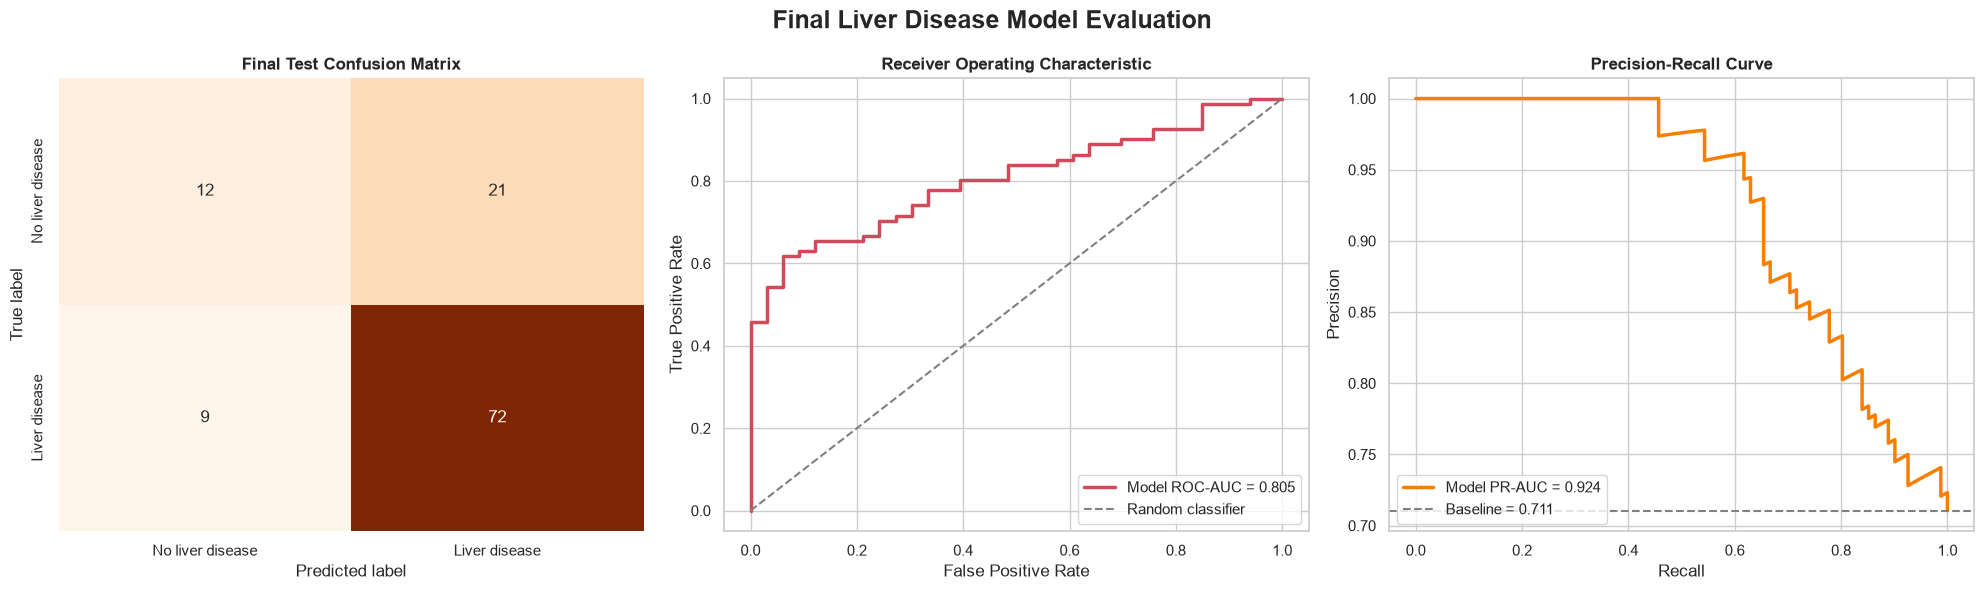

Evaluation figure saved: True
Evaluation figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\liver_final_model_evaluation.png


In [11]:
# Plot the final confusion matrix, ROC curve, and precision-recall curve
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_scores)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)
positive_prevalence = y_test.mean()

figure, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt=",",
    cmap="Oranges",
    cbar=False,
    xticklabels=["No liver disease", "Liver disease"],
    yticklabels=["No liver disease", "Liver disease"],
    ax=axes[0],
)
axes[0].set_title("Final Test Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    color="#D1495B",
    linewidth=2.5,
    label=f"Model ROC-AUC = {test_metrics['ROC-AUC']:.3f}",
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
axes[1].set_title("Receiver Operating Characteristic", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

axes[2].plot(
    recall_curve,
    precision_curve,
    color="#F77F00",
    linewidth=2.5,
    label=f"Model PR-AUC = {test_metrics['PR-AUC']:.3f}",
)
axes[2].axhline(
    positive_prevalence,
    linestyle="--",
    color="gray",
    label=f"Baseline = {positive_prevalence:.3f}",
)
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="lower left")

figure.suptitle("Final Liver Disease Model Evaluation", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig(evaluation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Evaluation figure saved:", evaluation_figure_path.exists())
print("Evaluation figure path:", evaluation_figure_path)

## 12. Permutation Feature Importance

Permutation importance measures how much balanced accuracy decreases when one feature is randomly shuffled.

A larger decrease indicates that the fitted model depends more strongly on that feature for prediction.

This is a model-interpretation technique and does not establish a causal relationship between a laboratory measurement and liver disease.


,Feature,Importance,Standard Deviation
0,albumin,0.1636,0.0413
1,direct_bilirubin,0.0294,0.0249
2,alanine_aminotransferase,0.0288,0.0288
3,albumin_globulin_ratio,0.0068,0.0268
4,total_bilirubin,0.0067,0.0111
5,alkaline_phosphatase,0.0052,0.0173
6,age,0.0033,0.0271
7,gender,0.0000,0.0000
8,total_proteins,-0.0010,0.0272
9,aspartate_aminotransferase,-0.0018,0.0195


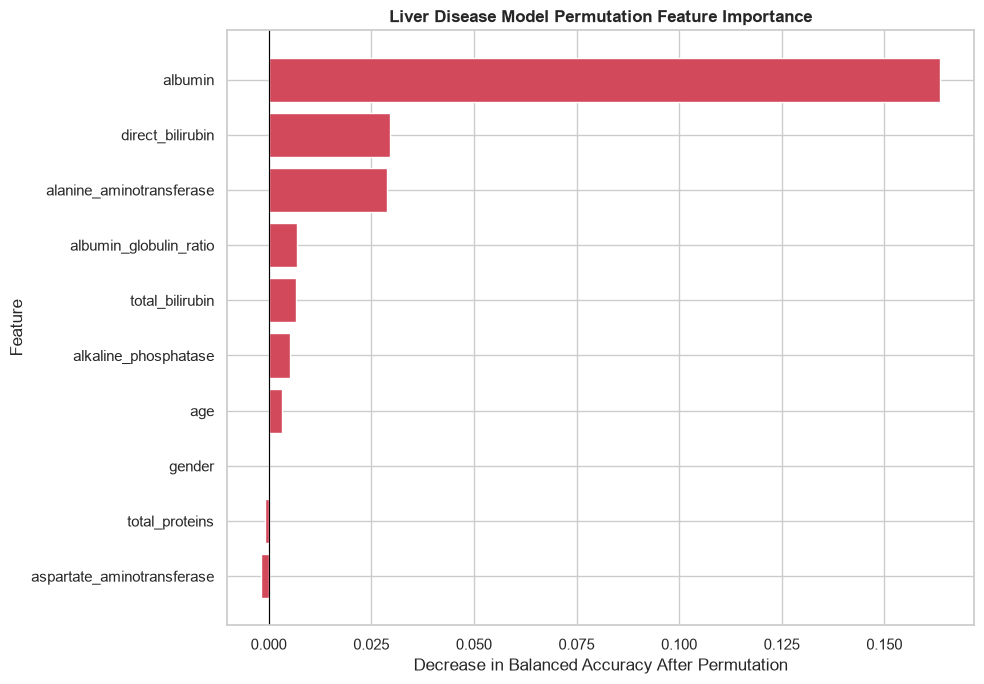

Feature importance figure saved: True
Feature importance figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\liver_feature_importance.png


In [12]:
# Calculate test-set permutation importance using balanced accuracy
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance": permutation.importances_mean,
        "Standard Deviation": permutation.importances_std,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

display(importance_table.round(4))

plot_table = importance_table.sort_values("Importance", ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(plot_table["Feature"], plot_table["Importance"], color="#D1495B")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Liver Disease Model Permutation Feature Importance", fontweight="bold")
plt.xlabel("Decrease in Balanced Accuracy After Permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(importance_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Feature importance figure saved:", importance_figure_path.exists())
print("Feature importance figure path:", importance_figure_path)

## 13. Saving the Liver-Disease Model Artifact

The final artifact stores the complete fitted pipeline together with deployment metadata:

- Selected model name.
- Decision threshold.
- Required feature names and feature groups.
- Class labels.
- Held-out test metrics.
- Dataset source and intended-use statement.

The saved artifact is reloaded and used for verification predictions so that Streamlit can later use exactly the same preprocessing and classification pipeline.


In [13]:
# Save the complete inference artifact
model_artifact = {
    "model": final_model,
    "model_name": selected_model_name,
    "threshold": selected_threshold,
    "features": X.columns.tolist(),
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "target": target_column,
    "class_labels": {0: "No liver disease", 1: "Liver disease"},
    "test_metrics": test_metrics,
    "subgroup_metrics": subgroup_results.reset_index().to_dict(orient="records"),
    "dataset_source": "UCI ILPD, DOI 10.24432/C5D02C",
    "intended_use": "Educational screening only; not a medical diagnosis.",
}

joblib.dump(model_artifact, model_path)

# Reload the saved artifact and verify inference
loaded_artifact = joblib.load(model_path)
verification_scores = loaded_artifact["model"].predict_proba(X_test.head())[:, 1]
verification_predictions = (
    verification_scores >= loaded_artifact["threshold"]
).astype(int)

print("Liver model saved successfully:", model_path.exists())
print("Saved model path:", model_path)
print("Saved model name:", loaded_artifact["model_name"])
print("Saved threshold:", loaded_artifact["threshold"])
print("Number of saved features:", len(loaded_artifact["features"]))
print("Verification scores:", np.round(verification_scores, 4))
print("Verification predictions:", verification_predictions)

Liver model saved successfully: True
Saved model path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\models\liver_disease_model.joblib
Saved model name: Logistic Regression
Saved threshold: 0.29499999999999993
Number of saved features: 10
Verification scores: [0.2227 0.1373 0.7895 0.288  0.2291]
Verification predictions: [0 0 1 0 0]


## Interpretation and limitations

- The dataset contains only 570 unique records after exact duplicate removal, so test and subgroup estimates have substantial uncertainty.
- The positive class is the majority; balanced accuracy and class-specific metrics are more informative than accuracy alone.
- The selected threshold is a model decision rule and not a clinical laboratory threshold.
- The model score must not be presented as a calibrated clinical probability unless calibration is separately evaluated.
- Sex-stratified results are descriptive and do not establish fairness because the female subgroup is small.
- Permutation importance measures predictive dependence in this sample and does not establish medical causation.
- External validation, calibration, subgroup auditing, and prospective clinical evaluation are required before real healthcare use.

### Dataset attribution

Ramana, B., & Venkateswarlu, N. (2022). *ILPD (Indian Liver Patient Dataset)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5D02C